# 4.基于 ResNet50 迁移学习的十种猴子图像分类（微调）

本章使用 PyTorch 加载预训练的 **ResNet50** 模型，通过**迁移学习（Transfer Learning）**与**微调（Fine-tuning）**策略，在 10 Monkey Species 数据集上实现高精度图像分类，体验大模型迁移能力带来的性能提升。

**主要内容：**
- 迁移学习与微调基本原理
- 加载 ImageNet 预训练 ResNet50 并修改分类头
- 分层学习率设置与微调策略
- 模型训练、验证与性能对比
- 使用 TensorBoard 可视化训练过程

## 一、导入依赖库与环境配置

导入本项目所需的所有 Python 库，检测计算环境（CPU/GPU），并打印各库版本以便调试与复现。

In [1]:
import matplotlib as mpl  # 导入 matplotlib 绘图库主模块，用于图形全局配置（如字体、DPI）
import matplotlib.pyplot as plt  # 导入 pyplot 子模块，提供类 MATLAB 的绘图接口，别名 plt
%matplotlib inline  
# Jupyter 魔法命令：使图表直接内嵌显示在 notebook 单元格中
import numpy as np  # 导入 NumPy 数值计算库，提供多维数组和数学函数，别名 np
import sklearn  # 导入 scikit-learn 机器学习库（此处仅用于打印版本号）
import pandas as pd  # 导入 Pandas 数据分析库，提供 DataFrame 结构，别名 pd
import os  # 导入操作系统接口模块，用于目录检测与创建等文件系统操作
import sys  # 导入系统模块，用于获取 Python 解释器版本信息
import time  # 导入时间模块，可用于计时（此处用于版本打印）
from tqdm import tqdm  # 导入 tqdm 进度条库，auto 版本自动适配 notebook/terminal 环境
import torch  # 导入 PyTorch 深度学习框架核心库
import torch.nn as nn  # 导入神经网络模块，包含各种层、损失函数和激活函数，别名 nn
import torch.nn.functional as F  # 导入函数式 API，提供无状态的神经网络函数（如 relu、softmax），别名 F

print(sys.version_info)  # 打印 Python 版本详细信息（类型: sys.version_info）
for module in mpl, np, pd, sklearn, torch:  # 遍历各主要依赖库对象
    print(module.__name__, module.__version__)  # 打印库名称（str）及安装的版本号（str）
    
# 检测 GPU 是否可用，优先使用 CUDA 设备，否则回退到 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的计算设备（输出 "cuda:0" 或 "cpu"）

seed = 42  # 设置随机种子值（int），用于后续保证实验可复现（需配合 torch.manual_seed 等使用）


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据集准备

10种猴子图片分类数据集（10 Monkey Species），包含训练集和验证集

In [2]:
from torchvision import datasets  # 从 torchvision 导入数据集模块，其中包含 ImageFolder 等常用视觉数据集类
from torchvision.transforms import ToTensor, Resize, Compose, ConvertImageDtype, Normalize,RandomRotation,RandomHorizontalFlip,RandomPerspective
# 导入图像变换操作：
# ToTensor: PIL 图像 -> Tensor 并缩放至 [0,1]
# Resize: 缩放图像尺寸
# Compose: 组合多个变换操作
# ConvertImageDtype: 转换像素值数据类型
# Normalize: 使用均值和标准差进行标准化


from pathlib import Path  # 导入 Path 类，用于面向对象的路径操作（跨平台）

DATA_DIR = Path("data/archive/")  # 数据集根目录路径（相对路径，类型: pathlib.Path）

class MonkeyDataset(datasets.ImageFolder):  # 自定义猴子分类数据集，继承自 torchvision 的 ImageFolder
    def __init__(self, mode, transform=None):  # 初始化方法
        # 参数说明：
        # mode: 数据集模式，取值为 "train" 或 "val"（类型: str）
        # transform: 图像预处理变换管道（类型: callable 或 None）
        if mode == "train":  # 若为训练模式
            root = DATA_DIR / "training"  # 指定训练数据目录路径（类型: pathlib.Path）
        elif mode == "val":  # 若为验证模式
            root = DATA_DIR / "validation"  # 指定验证数据目录路径（类型: pathlib.Path）
        else:  # 其他非法模式值
            raise ValueError("mode should be one of the following: train, val, but got {}".format(mode))  # 抛出值错误异常，提示合法取值
        super().__init__(root, transform)  # 调用父类 ImageFolder 的初始化，传入数据根目录和变换管道
        self.imgs = self.samples  # 将 samples 属性赋值给 imgs 属性，保持与旧版接口兼容
        self.targets = [s[1] for s in self.samples]  # 提取所有样本的标签列表（类型: list[int]）

# resnet 要求的，见 https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html
img_h, img_w = 224, 224  # ResNet50 要求的标准输入尺寸：高度 224 像素，宽度 224 像素
transform = Compose([  # 组合多个图像变换操作，构成数据预处理管道（类型: torchvision.transforms.Compose）
     Resize((img_h, img_w)),  # 将任意尺寸的图像缩放至 (224, 224)，满足 ResNet50 输入要求
     RandomRotation(45),
     RandomHorizontalFlip(p=0.5),
     RandomPerspective(distortion_scale=0.5, p=0.5),
     ToTensor(),  # 将 PIL 图像或 numpy.ndarray 转为 Tensor，并自动缩放像素值至 [0, 1]
     Normalize([0.4363, 0.4328, 0.3291], [0.2427, 0.2382, 0.2413]),  # 使用 ImageNet 数据集的 RGB 三通道均值和标准差进行标准化;notebook3中已经计算过
     ConvertImageDtype(torch.float),  # 将 Tensor 像素值转换为 float32 类型（torch.float）
])


train_ds = MonkeyDataset("train", transform=transform)  # 创建训练数据集实例（类型: MonkeyDataset）
val_ds = MonkeyDataset("val", transform=transform)  # 创建验证数据集实例（类型: MonkeyDataset）

print("load {} images from training dataset".format(len(train_ds)))  # 打印训练集图片总数（int）
print("load {} images from validation dataset".format(len(val_ds)))  # 打印验证集图片总数（int）

load 1097 images from training dataset
load 272 images from validation dataset


### 2.1 查看数据集类别名称与索引映射

In [3]:
# 数据类别
# 打印训练集所有类别名称列表
print(train_ds.classes)
# 打印类别到索引的映射字典
print(train_ds.class_to_idx)

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']
{'n0': 0, 'n1': 1, 'n2': 2, 'n3': 3, 'n4': 4, 'n5': 5, 'n6': 6, 'n7': 7, 'n8': 8, 'n9': 9}


### 2.2 查看图片路径与标签格式

In [4]:
# 图片路径 及 标签
for fpath, label in train_ds.imgs:  # 遍历 imgs 属性（每项为 (文件路径, 类别索引) 的二元组）
    print(fpath, label)  # 打印图片文件路径（str）和对应的类别索引（int）
    break  # 只查看第一个样本，立即退出循环

for img, label in train_ds:  # 通过迭代数据集获取经过预处理变换的图像张量和标签
    # c, h, w  label
    print(img.shape, label)  # 打印图像张量的形状 [通道数, 高度, 宽度]（torch.Size）和类别索引（int）
    break  # 只查看第一个样本，立即退出循环

data\archive\training\n0\n0018.jpg 0
torch.Size([3, 224, 224]) 0


### 2.4 创建批次数据加载器（DataLoader）

In [5]:
import torch.nn as nn  # 再次导入 nn 模块（保持代码块完整性，无副作用）
from torch.utils.data.dataloader import DataLoader  # 导入 DataLoader 类，用于批量、多进程加载数据集

batch_size = 32  # 每个批次加载的样本数量（int），通常根据显存大小调整
# 从数据集到dataloader
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  # 创建训练集数据加载器；shuffle=True 每个 epoch 开始前随机打乱样本顺序（类型: DataLoader）
val_loader = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False)  # 创建验证集数据加载器；shuffle=False 保持固定顺序，确保评估结果可复现（类型: DataLoader）

### 2.5 验证 DataLoader 输出的批次形状

In [6]:
for imgs, labels in train_loader:  # 从训练集 DataLoader 迭代获取一个批次数据（imgs 和 labels 均为 Tensor）
    print(imgs.shape)  # 打印图像批次张量形状，应为 torch.Size([16, 3, 224, 224])（批大小, 通道数, 高度, 宽度）
    print(labels.shape)  # 打印标签批次张量形状，应为 torch.Size([16])（批大小,）
    break  # 只查看第一个批次，立即退出循环

torch.Size([32, 3, 224, 224])
torch.Size([32])


## 三、定义模型（ResNet50 迁移学习）

基于 torchvision 提供的 ResNet50 预训练模型，通过迁移学习方式进行猴子分类任务的精调（Fine-tuning）：
- 加载 ImageNet 预训练权重（IMAGENET1K_V2）
- 冻结大部分层，只解冻 `layer4.2.conv3` 及新增分类头
- 将原始 1000 类全连接层替换为 10 类输出

In [7]:
from torchvision.models import resnet50  # 从 torchvision 导入 ResNet50 模型构造函数


# 加载resnet50模型以及预训练权重，冻结除最后一层外所有层的权重，去除最后一层并添加自定义分类层
class ResNet50(nn.Module):  # 自定义 ResNet50 迁移学习模型，继承自 nn.Module（PyTorch 模型基类）
    def __init__(self, num_classes=10, frozen=True):  # 初始化方法
        # 参数 num_classes: 目标分类类别数（int，默认 10，对应 10 种猴子）
        # 参数 frozen: 是否冻结 ResNet50 预训练权重（bool，默认 True）
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        # 下载预训练权重
        self.model = resnet50(weights="IMAGENET1K_V2",)  # 加载 ResNet50 并使用 ImageNet V2 预训练权重（最新版，精度更高）
        # 冻结前面的层
        if frozen:  # 若指定冻结预训练权重
            for param in self.model.parameters():  # 遍历模型所有参数
                param.requires_grad = False  # 将该参数的梯度计算设为 False，即冻结（不参与反向传播和权重更新）
        # for param in self.model.layer4.parameters():
        #     param.requires_grad = True  # 解冻 layer4（注释掉的备用解冻方案）
        for name, param in self.model.named_parameters():  # 遍历所有具名参数（name: 参数全名 str，param: 参数张量 Tensor）
            if name == "layer4.2.conv3.weight":  # 判断是否为 layer4 第3个 Bottleneck 的 conv3 卷积权重（精调关键层）
                param.requires_grad = True  # 解冻该特定层，使其在训练时更新权重
        # 添加自定义分类层
        # print(self.model)  # 打印完整 ResNet50 模型结构（注释掉，调试时使用）
        # print(self.model.fc.in_features)  # 打印原始全连接层的输入特征维度（ResNet50 默认为 2048）
        # print(self.model.fc.out_features)  # 打印原始全连接层的输出维度（ImageNet 预训练为 1000 类）
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)  # 替换原始全连接层为自定义分类头：输入 2048 维 -> 输出 num_classes 维
        
        
    def forward(self, x):  # 前向传播方法
        # 参数 x: 输入图像批次（Tensor，shape: [N, 3, H, W]，其中 N 为批大小）
        # 返回值: 分类 logits（Tensor，shape: [N, num_classes]，未经 softmax 的原始得分）
        return self.model(x)  # 调用完整 ResNet50 模型进行前向传播，返回分类 logits


for idx, (key, value) in enumerate(ResNet50().named_parameters()):  # 实例化 ResNet50 模型并遍历所有具名参数
    # idx: 参数序号（int），key: 参数全路径名（str），value: 参数张量（Tensor）
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")  # 打印参数名（居中对齐40字符）及参数总量（形状各维度之积）


           model.conv1.weight           paramerters num: 9408
            model.bn1.weight            paramerters num: 64
             model.bn1.bias             paramerters num: 64
      model.layer1.0.conv1.weight       paramerters num: 4096
       model.layer1.0.bn1.weight        paramerters num: 64
        model.layer1.0.bn1.bias         paramerters num: 64
      model.layer1.0.conv2.weight       paramerters num: 36864
       model.layer1.0.bn2.weight        paramerters num: 64
        model.layer1.0.bn2.bias         paramerters num: 64
      model.layer1.0.conv3.weight       paramerters num: 16384
       model.layer1.0.bn3.weight        paramerters num: 256
        model.layer1.0.bn3.bias         paramerters num: 256
   model.layer1.0.downsample.0.weight   paramerters num: 16384
   model.layer1.0.downsample.1.weight   paramerters num: 256
    model.layer1.0.downsample.1.bias    paramerters num: 256
      model.layer1.1.conv1.weight       paramerters num: 16384
       model.layer1.

### 3.1 统计模型可训练参数量

In [8]:
model = ResNet50(num_classes=10, frozen=True)  # 实例化 ResNet50 迁移学习模型：10 类猴子分类，冻结预训练权重
def count_parameters(model):  # 函数功能：统计模型中所有可训练参数（requires_grad=True）的总量
    # 参数 model: PyTorch 模型（类型: nn.Module）
    # 返回值: 可训练参数总数（类型: int）
    return sum(p.numel() for p in model.parameters() if p.requires_grad)  # 遍历模型参数，仅对可训练参数求元素数之和
count_parameters(model)  # 调用函数，输出当前模型的可训练参数总量

1069066

### 3.2 打印完整模型结构

In [9]:
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

model.conv1.weight: torch.Size([64, 3, 7, 7])
model.bn1.weight: torch.Size([64])
model.bn1.bias: torch.Size([64])
model.layer1.0.conv1.weight: torch.Size([64, 64, 1, 1])
model.layer1.0.bn1.weight: torch.Size([64])
model.layer1.0.bn1.bias: torch.Size([64])
model.layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
model.layer1.0.bn2.weight: torch.Size([64])
model.layer1.0.bn2.bias: torch.Size([64])
model.layer1.0.conv3.weight: torch.Size([256, 64, 1, 1])
model.layer1.0.bn3.weight: torch.Size([256])
model.layer1.0.bn3.bias: torch.Size([256])
model.layer1.0.downsample.0.weight: torch.Size([256, 64, 1, 1])
model.layer1.0.downsample.1.weight: torch.Size([256])
model.layer1.0.downsample.1.bias: torch.Size([256])
model.layer1.1.conv1.weight: torch.Size([64, 256, 1, 1])
model.layer1.1.bn1.weight: torch.Size([64])
model.layer1.1.bn1.bias: torch.Size([64])
model.layer1.1.conv2.weight: torch.Size([64, 64, 3, 3])
model.layer1.1.bn2.weight: torch.Size([64])
model.layer1.1.bn2.bias: torch.Size([64])
mo

### 3.3 统计模型总参数量（含冻结层）

In [10]:
total_params = sum(p.numel() for p in model.parameters())  # 统计模型所有参数（含冻结层）的总量；p.numel() 返回张量元素个数（int）
print(f"Total trainable parameters: {total_params}")  # 打印模型全部参数总量（含冻结参数，非实际可训练量）

Total trainable parameters: 23528522


### 3.4 自适应平均池化（AdaptiveAvgPool2d）验证

In [11]:
m = nn.AdaptiveAvgPool2d(output_size=(1, 1))  # 创建自适应平均池化层，将任意空间尺寸的特征图压缩为 (1, 1)（类型: nn.AdaptiveAvgPool2d）
input = torch.randn(1, 2048, 9, 9)  # 创建随机输入张量，模拟 ResNet50 layer4 的输出特征图（shape: [1, 2048, 9, 9]）
output = m(input)  # 通过自适应平均池化层进行前向传播，输出 shape 应为 [1, 2048, 1, 1]
output.shape  # 查看并验证输出张量形状，应为 torch.Size([1, 2048, 1, 1])

torch.Size([1, 2048, 1, 1])

## 四、模型训练

PyTorch 训练需要手动实现完整训练循环，主要包含以下步骤：
1. 定义损失函数（交叉熵）
2. 定义优化器（SGD）
3. 实现评估函数
4. 实现训练步（前向计算 → 损失计算 → 梯度回传 → 参数更新）
5. 配置训练回调（TensorBoard、模型保存、早停）

### 4.1 定义验证集评估函数

In [12]:
from sklearn.metrics import accuracy_score  # 从 sklearn 导入准确率计算函数
# accuracy_score(y_true, y_pred) -> float: 计算分类准确率（正确预测数/总预测数，范围 [0, 1]）

@torch.no_grad()  # 装饰器：在评估推理时禁用梯度计算，节省内存并加速（等效于 with torch.no_grad(): 块）
def evaluating(model, dataloader, loss_fct):  # 验证集评估函数
    # 参数 model: 待评估模型（类型: nn.Module）
    # 参数 dataloader: 验证集数据加载器（类型: DataLoader）
    # 参数 loss_fct: 损失函数（类型: nn.Module，如 CrossEntropyLoss）
    # 返回值: (平均损失值, 准确率)（类型: tuple[float, float]）
    loss_list = []  # 初始化损失值列表，收集每个批次的损失标量（list[float]）
    pred_list = []  # 初始化预测标签列表，收集所有批次的预测类别（list[int]）
    label_list = []  # 初始化真实标签列表，收集所有批次的真实类别（list[int]）
    model.eval()  # 切换为评估模式，关闭 Dropout 和 BatchNorm 的训练行为
    for datas, labels in dataloader:  # 遍历验证集数据加载器，datas: 图像批次（Tensor），labels: 标签批次（Tensor）
        datas = datas.to(device)  # 将图像数据迁移到指定计算设备（CPU 或 GPU）
        labels = labels.to(device)  # 将标签数据迁移到指定计算设备（CPU 或 GPU）
        # 前向计算
        logits = model(datas)  # 前向传播：输入图像批次，输出分类 logits（Tensor, shape: [N, num_classes]）
        loss = loss_fct(logits, labels)  # 计算当前批次的交叉熵损失（返回标量 Tensor）
        loss_list.append(loss.item())  # 将损失张量转为 Python 标量（float）并追加到列表
        
        preds = logits.argmax(axis=-1)  # 沿最后一维（类别维度）取最大值的索引，得到预测类别（Tensor, shape: [N]）
        pred_list.extend(preds.cpu().numpy().tolist())  # 将预测标签迁移至 CPU -> numpy 数组 -> Python 列表，追加到总预测列表
        label_list.extend(labels.cpu().numpy().tolist())  # 将真实标签迁移至 CPU -> numpy 数组 -> Python 列表，追加到总标签列表
        
    acc = accuracy_score(label_list, pred_list)  # 计算整个验证集的分类准确率（float，范围 [0, 1]）
    return np.mean(loss_list), acc  # 返回批次平均损失值（float）和整体准确率（float）


### 4.2 TensorBoard 可视化回调

训练过程中可以使用如下命令启动 TensorBoard 服务进行实时可视化监控：

```shell
tensorboard \
    --logdir=runs \     # log 存放路径
    --host 0.0.0.0 \    # ip
    --port 8848         # 端口
```

In [13]:
from torch.utils.tensorboard import SummaryWriter  # 导入 TensorBoard 的 SummaryWriter，用于将训练指标写入日志文件


class TensorBoardCallback:  # TensorBoard 可视化回调类，封装训练过程中损失、准确率和学习率的记录逻辑
    def __init__(self, log_dir, flush_secs=10):  # 初始化方法
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        # 参数 log_dir: TensorBoard 日志存储目录路径（str）
        # 参数 flush_secs: 日志刷新磁盘的时间间隔（int，单位秒，默认 10）
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)  # 创建 SummaryWriter 实例，负责将数据写入 TensorBoard 日志文件

    def draw_model(self, model, input_shape):  # 在 TensorBoard 中可视化模型计算图
        # 参数 model: 待可视化的模型（类型: nn.Module）
        # 参数 input_shape: 模型输入张量的形状（类型: list 或 tuple，如 [1, 3, 224, 224]）
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))  # 使用随机输入张量触发前向传播，记录计算图到 TensorBoard
        
    def add_loss_scalars(self, step, loss, val_loss):  # 记录训练集和验证集的损失值曲线
        # 参数 step: 当前全局训练步数（int，作为横轴坐标）
        # 参数 loss: 当前训练批次的损失值（float）
        # 参数 val_loss: 当前验证集的平均损失值（float）
        self.writer.add_scalars(
            main_tag="training/loss",  # 主标签，对应 TensorBoard 面板中的分组名称
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 多条曲线的标签-数值字典
            global_step=step,  # 横轴步数（int）
            )
        
    def add_acc_scalars(self, step, acc, val_acc):  # 记录训练集和验证集的准确率曲线
        # 参数 step: 全局训练步数（int）
        # 参数 acc: 当前训练批次的准确率（float，范围 [0, 1]）
        # 参数 val_acc: 当前验证集的准确率（float，范围 [0, 1]）
        self.writer.add_scalars(
            main_tag="training/accuracy",  # 准确率面板的分组名称
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},  # 训练和验证准确率的标签-数值字典
            global_step=step,  # 横轴步数（int）
        )
        
    def add_lr_scalars(self, step, learning_rate):  # 记录学习率随步数的变化曲线
        # 参数 step: 全局训练步数（int）
        # 参数 learning_rate: 当前学习率值（float）
        self.writer.add_scalars(
            main_tag="training/learning_rate",  # 学习率面板的分组名称
            tag_scalar_dict={"learning_rate": learning_rate},  # 学习率标签-数值字典
            global_step=step,  # 横轴步数（int）
            
        )
    
    def __call__(self, step, **kwargs):  # 使实例可像函数一样直接调用，统一调度所有指标的记录
        # 参数 step: 全局训练步数（int）
        # 参数 **kwargs: 可选关键字参数，支持 loss, val_loss, acc, val_acc, lr
        # add loss
        loss = kwargs.pop("loss", None)  # 从 kwargs 中弹出训练损失值（float 或 None）
        val_loss = kwargs.pop("val_loss", None)  # 从 kwargs 中弹出验证损失值（float 或 None）
        if loss is not None and val_loss is not None:  # 当训练和验证损失均有效时才记录
            self.add_loss_scalars(step, loss, val_loss)  # 调用损失记录方法
        # add acc
        acc = kwargs.pop("acc", None)  # 从 kwargs 中弹出训练准确率（float 或 None）
        val_acc = kwargs.pop("val_acc", None)  # 从 kwargs 中弹出验证准确率（float 或 None）
        if acc is not None and val_acc is not None:  # 当训练和验证准确率均有效时才记录
            self.add_acc_scalars(step, acc, val_acc)  # 调用准确率记录方法
        # add lr
        learning_rate = kwargs.pop("lr", None)  # 从 kwargs 中弹出当前学习率（float 或 None）
        if learning_rate is not None:  # 当学习率有效时才记录
            self.add_lr_scalars(step, learning_rate)  # 调用学习率记录方法


### 4.3 保存最佳模型回调（Save Best Checkpoint）

在每次验证评估后，若当前验证指标（准确率）优于历史最优，则保存当前模型权重为 `best.ckpt`，确保最终保留性能最优的模型。

In [14]:
class SaveCheckpointsCallback:  # 模型检查点保存回调类，在验证指标改善时保存最优模型权重
    def __init__(self, save_dir, save_best_only=True):  # 初始化方法
        """
        以验证步为间隔保存模型

        Args:
            save_dir (str): dir to save checkpoint
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        # 参数 save_dir: 检查点文件的保存目录路径（str）
        # 参数 save_best_only: 是否只保存验证指标最优的模型（bool，默认 True）
        self.save_dir = save_dir  # 保存目录路径（str）
        self.save_best_only = save_best_only  # 是否只保存最佳模型标志（bool）
        self.best_metrics = -1  # 初始化历史最优指标值（float），-1 表示尚未有有效记录
        
        if not os.path.exists(self.save_dir):  # 检查保存目录是否存在
            os.makedirs(self.save_dir)  # 若不存在则创建目录
        
    def __call__(self, step, state_dict, metric=None):  # 使实例可调用，在每次验证后由训练循环调用
        # 参数 step: 当前全局训练步数（int）
        # 参数 state_dict: 模型状态字典（dict），包含所有参数张量
        # 参数 metric: 当前验证集评估指标（float 或 None，如验证准确率）
        
        if self.save_best_only:  # 若设置为只保存最佳模型
            assert metric is not None  # 断言 metric 不为 None，必须提供评估指标值
            if metric >= self.best_metrics:  # 若当前指标优于或等于历史最优指标
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "4_model_best.ckpt"))  # 将模型状态字典保存为 "best.ckpt" 文件（覆盖旧的最优检查点）
                # update best metrics
                self.best_metrics = metric  # 更新历史最优指标值
        else:  # 若设置为保存每个检查点
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))  # 以当前步数为文件名保存检查点（不覆盖历史记录）



### 4.4 早停回调（Early Stop）

当验证集指标在连续 `patience` 次评估中均未显著提升（提升量 < `min_delta`）时，提前终止训练，防止模型过拟合。

In [15]:
class EarlyStopCallback:  # 早停回调类：当验证指标在连续多轮内未改善时，停止训练以防止过拟合
    def __init__(self, patience=5, min_delta=0.01):  # 初始化方法
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        # 参数 patience: 允许连续无改善的最大轮数（int，默认 5）；超过此数则触发早停
        # 参数 min_delta: 认定为有效改善的最小变化量阈值（float，默认 0.01）；小于此值视为未改善
        self.patience = patience  # 最大允许连续无改善轮数（int）
        self.min_delta = min_delta  # 判断是否改善的最小阈值（float）
        self.best_metric = -1  # 初始化历史最优指标值（float），-1 表示训练未开始
        self.counter = 0  # 初始化连续无改善计数器（int），从 0 开始
        
    def __call__(self, metric):  # 使实例可调用，每次验证后由训练循环调用以更新计数器
        # 参数 metric: 当前轮次的验证集评估指标值（float，如准确率）
        if metric >= self.best_metric + self.min_delta:  # 若当前指标超过历史最优值 + 最小改善量（认定为有效改善）
            # update best metric
            self.best_metric = metric  # 更新历史最优指标
            # reset counter 
            self.counter = 0  # 重置连续无改善计数器
        else:  # 若改善量不足（视为本轮未改善）
            self.counter += 1  # 连续无改善计数加 1
            
    @property
    def early_stop(self):  # 属性：判断是否应触发早停（只读 property，无需括号调用）
        # 返回值: bool；当连续无改善次数达到 patience 时返回 True
        return self.counter >= self.patience  # 若计数器 >= patience，触发早停条件


### 4.5 定义训练主循环并执行训练

In [16]:
%%time

# 训练
def training(  # 主训练函数：实现完整的前向传播、反向传播、评估与回调调度
    model,  # 待训练的模型（类型: nn.Module）
    train_loader,  # 训练集数据加载器（类型: DataLoader）
    val_loader,  # 验证集数据加载器（类型: DataLoader）
    epoch,  # 总训练轮数（类型: int）
    loss_fct,  # 损失函数（类型: nn.Module，如 CrossEntropyLoss）
    optimizer,  # 优化器（类型: torch.optim.Optimizer，如 SGD、Adam）
    tensorboard_callback=None,  # TensorBoard 可视化回调（类型: TensorBoardCallback 或 None）
    save_ckpt_callback=None,  # 检查点保存回调（类型: SaveCheckpointsCallback 或 None）
    early_stop_callback=None,  # 早停回调（类型: EarlyStopCallback 或 None）
    eval_step=500,  # 每隔多少步进行一次验证评估（类型: int，默认 500）
    ):
    record_dict = {  # 初始化训练记录字典（dict），存储训练和验证过程中的所有指标
        "train": [],  # 训练指标记录列表（list[dict]），每项含 loss, acc, step
        "val": []  # 验证指标记录列表（list[dict]），每项含 loss, acc, step
    }
    
    global_step = 0  # 初始化全局训练步数计数器（int），跨越所有 epoch 累计
    model.train()  # 将模型切换为训练模式（启用 Dropout 和 BatchNorm 的训练行为）
    with tqdm(total=epoch * len(train_loader)) as pbar:  # 创建进度条，总步数为 epoch 数 × 每轮批次数
        for epoch_id in range(epoch):  # 外层循环：遍历每个训练轮次（epoch_id: int，范围 [0, epoch-1]）
            # training
            for datas, labels in train_loader:  # 内层循环：遍历训练集中的每个批次
                datas = datas.to(device)  # 将图像批次数据迁移到计算设备（CPU 或 GPU）
                labels = labels.to(device)  # 将标签批次数据迁移到计算设备（CPU 或 GPU）
                # 梯度清空
                optimizer.zero_grad()  # 清空优化器中所有参数的累积梯度（每次反向传播前必须清零）
                # 模型前向计算
                logits = model(datas)  # 前向传播：得到分类 logits（Tensor, shape: [N, num_classes]）
                # 计算损失
                loss = loss_fct(logits, labels)  # 计算交叉熵损失（返回标量 Tensor）
                # 梯度回传
                loss.backward()  # 反向传播：计算损失对所有可训练参数的梯度
                # 调整优化器，包括学习率的变动等
                optimizer.step()  # 根据梯度更新模型参数（执行一步 SGD/Adam 等优化算法）
                preds = logits.argmax(axis=-1)  # 沿类别维度取最大值的索引，得到预测类别（Tensor, shape: [N]）
            
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())  # 计算当前批次的分类准确率（float）
                loss = loss.cpu().item()  # 将损失张量转为 Python 标量（float）
                # record
                
                record_dict["train"].append({  # 将当前步的训练指标追加到记录字典
                    "loss": loss, "acc": acc, "step": global_step  # 损失（float），准确率（float），全局步数（int）
                })
                
                # evaluating
                if global_step % eval_step == 0:  # 每隔 eval_step 步进行一次验证评估
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)  # 在验证集上计算平均损失和准确率
                    record_dict["val"].append({  # 将当前验证指标追加到记录字典
                        "loss": val_loss, "acc": val_acc, "step": global_step  # 验证损失（float），验证准确率（float），步数（int）
                    })
                    model.train()  # 验证结束后切换回训练模式
                    
                    # 1. 使用 tensorboard 可视化
                    if tensorboard_callback is not None:  # 若已提供 TensorBoard 回调实例
                        tensorboard_callback(  # 调用 TensorBoardCallback 记录当前步的所有指标
                            global_step, 
                            loss=loss, val_loss=val_loss,  # 传入训练和验证损失
                            acc=acc, val_acc=val_acc,  # 传入训练和验证准确率
                            lr=optimizer.param_groups[0]["lr"],  # 从优化器第一个参数组获取当前学习率（float）
                            )
                
                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:  # 若已提供检查点保存回调实例
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)  # 传入步数、模型状态字典和验证准确率

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:  # 若已提供早停回调实例
                        early_stop_callback(val_acc)  # 更新早停计数器（传入当前验证准确率）
                        if early_stop_callback.early_stop:  # 判断是否满足早停条件
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")  # 打印早停发生的位置信息
                            return record_dict  # 提前结束训练，返回已收集的记录字典
                    
                # udate step
                global_step += 1  # 全局步数加 1
                pbar.update(1)  # 进度条推进 1 步
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条后缀实时显示当前 epoch 编号
        
    return record_dict  # 训练完成后返回完整的训练记录字典（dict）
        

epoch = 20  # 设置总训练轮数（int）

model = ResNet50(num_classes=10)  # 实例化 ResNet50 迁移学习模型（类别数 10，默认 frozen=True 冻结预训练层）

# 1. 定义损失函数 采用交叉熵损失
loss_fct = nn.CrossEntropyLoss()  # 多分类交叉熵损失函数（内部集成了 log_softmax 和 NLLLoss）
# 2. 定义优化器 采用 sgd
# Optimizers specified in the torch.optim package
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.0)  # SGD 优化器；lr=0.01（学习率），momentum=0.0（无动量，即纯随机梯度下降）

# # 1. tensorboard 可视化
# if not os.path.exists("tensorboard_logs"):  # 检查 TensorBoard 日志目录是否存在
#     os.mkdir("tensorboard_logs")  # 若不存在则创建 "runs" 目录
# tensorboard_callback = TensorBoardCallback("runs/monkeys-resnet50")  # 初始化 TensorBoard 回调（注释掉，此次训练不使用）
# tensorboard_callback.draw_model(model, [1, 3, img_h, img_w])  # 可视化模型计算图（注释掉）
# 2. save best
save_ckpt_callback = SaveCheckpointsCallback(os.path.join("model_checkpoints","4_model"), save_best_only=True)  # 创建检查点保存回调
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=10)  # 创建早停回调，连续 10次验证无改善则停止训练

model = model.to(device)  # 将模型移动到指定计算设备（CPU 或 GPU）
eval_step=len(train_loader)//2
record = training(  # 执行训练主循环，返回训练记录字典（dict）
    model,  # 待训练的 ResNet50 模型
    train_loader,  # 训练集数据加载器
    val_loader,  # 验证集数据加载器
    epoch,  # 总训练轮数（20）
    loss_fct,  # 损失函数（CrossEntropyLoss）
    optimizer,  # 优化器（SGD，lr=0.01）
    tensorboard_callback=None,  # 不使用 TensorBoard 回调（设为 None）
    save_ckpt_callback=save_ckpt_callback,  # 使用检查点保存回调
    early_stop_callback=early_stop_callback,  # 使用早停回调
    eval_step=eval_step
    )

 51%|█████     | 357/700 [03:27<03:19,  1.72it/s, epoch=10]

Early stop at epoch 10 / global_step 357
CPU times: total: 1h 15min 53s
Wall time: 3min 28s


### 4.6 绘制损失与准确率学习曲线

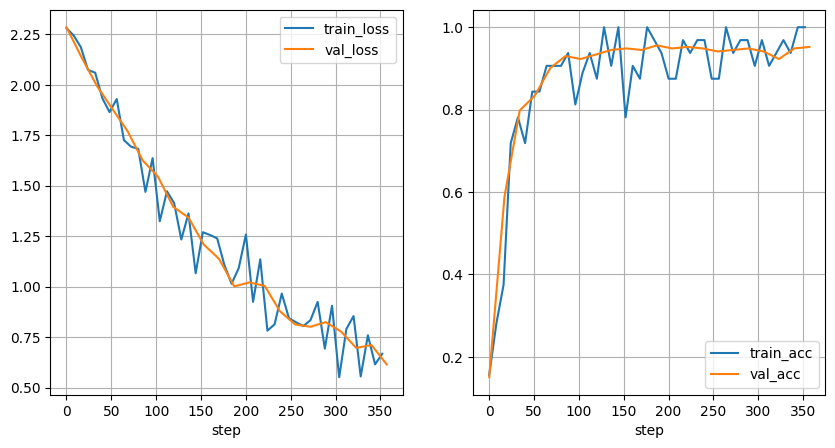

In [19]:
# 注意：注释说明损失值不一定能降到 1 以下
sample_step=eval_step//2
def plot_learning_curves(record_dict, sample_step=500):  # 函数功能：绘制训练和验证的损失/准确率学习曲线
    # 参数 record_dict: 训练记录字典（dict），含 "train" 和 "val" 两个键，每个值为指标记录列表
    # 参数 sample_step: 训练曲线降采样间隔（int，默认 500），用于减少曲线点数提升可读性
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]  # 将训练记录转为 DataFrame，以 step 为索引，每隔 sample_step 步取一个点（降采样）
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")  # 将验证记录转为 DataFrame，以 step 为索引（验证频率低，无需降采样）

    # plot
    fig_num = len(train_df.columns)  # 获取需要绘制的指标数量（如 loss 和 acc 共 2 个子图）
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))  # 创建 1 行 fig_num 列的子图布局，每个子图宽 5 英寸
    for idx, item in enumerate(train_df.columns):  # 遍历每个指标列名（如 "loss", "acc"）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 绘制训练指标曲线（横轴为步数，纵轴为指标值）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")  # 绘制验证指标曲线（横轴为步数，纵轴为指标值）
        axs[idx].grid()  # 开启网格线，便于对齐读取数值
        axs[idx].legend()  # 显示图例（标注 train_loss/val_loss 等曲线名称）
        # axs[idx].set_xticks(range(0, train_df.index[-1], 5000))  # 自定义 x 轴刻度位置（注释掉）
        # axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))  # 将刻度标签格式化为 "Xk" 形式（注释掉）
        axs[idx].set_xlabel("step")  # 设置 x 轴标签为 "step"（全局训练步数）
    
    plt.show()  # 在 notebook 中渲染并显示所有子图

plot_learning_curves(record, sample_step)  # 调用绘图函数，训练曲线每 10 步采样一点（record: 训练记录字典）

## 五、模型评估

加载训练阶段保存的最优模型权重，在验证集上进行最终性能评估，输出分类损失和准确率。

In [20]:
# dataload for evaluating

# load checkpoints
model.load_state_dict(torch.load("model_checkpoints/4_model/4_model_best.ckpt", map_location="cpu"))  # 加载训练阶段保存的最优模型权重
# map_location="cpu" 确保在无 GPU 环境下也能加载权重文件
# load_state_dict 将权重数据直接加载进已有模型对象，返回 None

loss, acc = evaluating(model, val_loader, loss_fct)  # 在验证集上执行推理评估
# 返回值：loss（float，平均损失），acc（float，分类准确率，范围 [0, 1]）
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")  # 打印最终验证集损失（保留 4 位小数）和准确率（保留 4 位小数）

loss:     1.0632
accuracy: 0.9375
